<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

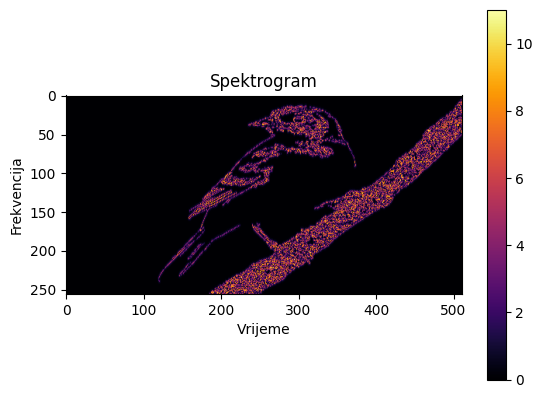

In [14]:
!pip install librosa soundfile opencv-python -q

import numpy as np
import cv2 as cv
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from google.colab import files
import IPython.display as ipd


img = cv.imread("Data/bird.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

img = cv.Canny(img, 50, 150)

img = cv.resize(img, (512, 256))

audio = librosa.griffinlim(img, n_iter=128, hop_length=256, n_fft=510)

audio = audio / np.abs(audio).max()

ipd.display(ipd.Audio(audio, rate=44100))

sf.write("zvuk.wav", audio, 44100)
files.download("zvuk.wav")

spectogram = np.abs(librosa.stft(audio, n_fft=510, hop_length=256))

plt.imshow(spectogram, cmap="inferno")
plt.title("Spektrogram")
plt.xlabel("Vrijeme")
plt.ylabel("Frekvencija")
plt.colorbar()
plt.show()
